<a href="https://colab.research.google.com/github/elizaabethnguyen/deepfake-detection/blob/main/deepfake_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [49]:
# LOADING DATA

In [50]:
# Test GPU
import torch

print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

True
Tesla T4


In [51]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [52]:
# Extract CelebA
import zipfile

zip_path = '/content/drive/MyDrive/img_align_celeba.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/celeba')

print("Extraction complete")

Extraction complete


In [53]:
# Verify Extraction
import os

print(os.listdir('/content/celeba')[:5])

['img_align_celeba']


In [54]:
# Load Dataset
import torchvision.datasets as dset
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

dataset = dset.ImageFolder(
    root='/content/celeba',
    transform=transform
)

print("Dataset size:", len(dataset))

Dataset size: 202599


In [55]:
# PRE - PROCESSING

In [56]:
# Creating smaller subset
from torch.utils.data import Subset

subset_indices = list(range(5000))

dataset = Subset(dataset, subset_indices)

print("Subset size:", len(dataset))

Subset size: 5000


In [57]:
# Creating DataLoader > helps model efficiently receive the images during training > in small batches
import torch

BATCH_SIZE = 64

dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

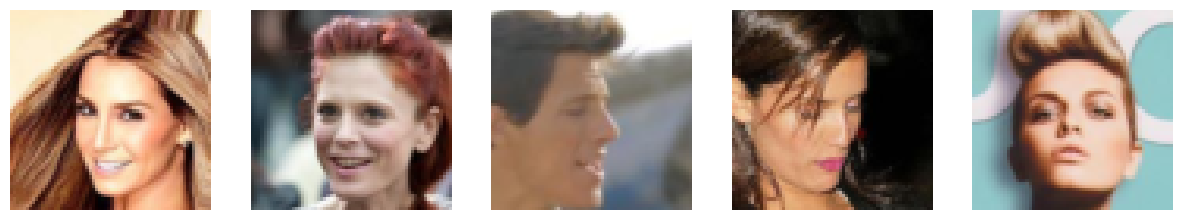

In [58]:
# Visualising Sample Set
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1,5, figsize=(15,5)) #1 row and 5 columns

for i in range(5):
    img, _ = dataset[i] # gets an image from the dataset.

    img = img.permute(1,2,0) #This rearranges the image dimensions.HWC
    img = (img + 1) / 2 # This rescales pixel values.

    axes[i].imshow(img) # displays the image in the i-th slot
    axes[i].axis('off')

plt.show()

In [59]:
# Hyperparameter Optimization

In [164]:
# Defining GAN Hyperparameters

# Import PyTorch neural network module
import torch.nn as nn

# Size of the random noise vector fed into the Generator
# The "seed" used to create a fake face > Random Noise → Generator → Fake Face
NZ = 100

# Generator feature size
# Bigger = more complex generator
NGF = 64

# Discriminator feature size
# Bigger = more complex discriminator > detector
NDF = 64

# Number of colour channels
# 3 because CelebA images are RGB
NC = 3

In [165]:
# Generator Network > Creates Fake Faces

class Generator(nn.Module):

    def __init__(self):

        # Initialise parent neural network class
        super().__init__()

        # Sequential means layers run one after another
        self.main = nn.Sequential(

            # =========================
            # LAYER 1 > learn rough structure where eyes/mouth/head might go
            # =========================

            nn.ConvTranspose2d(
                NZ,        # input channels (noise vector)
                NGF * 8,   # output channels
                4,         # kernel size
                1,         # stride
                0,         # padding
                bias=False
            ),

            # Helps stabilise training
            nn.BatchNorm2d(NGF * 8),

            # Activation function
            # Keeps positive values and removes negatives
            nn.ReLU(True),

            # =========================
            # LAYER 2 > add shape and facial features
            # =========================

            # Upsamples image size
            # Makes feature map bigger
            nn.ConvTranspose2d(  # ConvTranspose2d layer enlarges the image.
                NGF * 8,
                NGF * 4,
                4,
                2,
                1,
                bias=False
            ),

            nn.BatchNorm2d(NGF * 4), #Keeps the AI balanced while learning
            nn.ReLU(True), #Helps the AI think in more complex ways

            # =========================
            # LAYER 3 > add shape and facial features
            # =========================

            nn.ConvTranspose2d(
                NGF * 4,
                NGF * 2,
                4,
                2,
                1,
                bias=False
            ),

            nn.BatchNorm2d(NGF * 2),
            nn.ReLU(True),

            # =========================
            # LAYER 4 > add shape and facial features
            # =========================

            nn.ConvTranspose2d(
                NGF * 2,
                NGF,
                4,
                2,
                1,
                bias=False
            ),

            nn.BatchNorm2d(NGF),
            nn.ReLU(True),

            # =========================
            # FINAL LAYER > add colour and fine detail
            # =========================

            # Converts features into a final RGB image
            nn.ConvTranspose2d(.
                NGF,
                NC,
                4,
                2,
                1,
                bias=False
            ),

            # Squashes values between -1 and 1
            nn.Tanh() #matches how your training images were scaled
        )

    # Defines forward pass through network
    def forward(self, x): #Take the input and pass it through all the layers

        # Pass input through all layers
        return self.main(x)

In [166]:
# Discriminator Network > Detects Real vs Fake

class Discriminator(nn.Module):

    def __init__(self):

        super().__init__()

        self.main = nn.Sequential(

            # =========================
            # LAYER 1
            # =========================

            # Reads image and extracts features > layers scan the image looking for patterns.
            nn.Conv2d(
                NC,        # RGB image input
                NDF,
                4,
                2,
                1,
                bias=False
            ),

            # Allows small negative values
            # Helps GAN training stability
            nn.LeakyReLU(0.2, inplace=True),

            # =========================
            # LAYER 2
            # =========================

            nn.Conv2d(
                NDF,
                NDF * 2,
                4,
                2,
                1,
                bias=False
            ),

            nn.BatchNorm2d(NDF * 2),
            nn.LeakyReLU(0.2, inplace=True),

            # =========================
            # LAYER 3
            # =========================

            nn.Conv2d(
                NDF * 2,
                NDF * 4,
                4,
                2,
                1,
                bias=False
            ),

            nn.BatchNorm2d(NDF * 4),
            nn.LeakyReLU(0.2, inplace=True),

            # =========================
            # LAYER 4
            # =========================

            nn.Conv2d(
                NDF * 4,
                NDF * 8,
                4,
                2,
                1,
                bias=False
            ),

            nn.BatchNorm2d(NDF * 8),
            nn.LeakyReLU(0.2, inplace=True),

            # =========================
            # FINAL LAYER
            # =========================

            # Outputs a single value:
            # 1 = real image
            # 0 = fake image
            nn.Conv2d(
                NDF * 8,
                1,
                4,
                1,
                0,
                bias=False
            ),

            # Converts output into probability between 0 and 1
            nn.Sigmoid()
        )

    def forward(self, x): # > Defines how the image moves through the network.

        # Flatten output into 1D vector
        return self.main(x).view(-1)


In [167]:
# Initialise Models
# Use GPU if available
# setting up your GAN models and preparing them for training.
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Create Generator object
netG = Generator().to(device)

# Create Discriminator object
netD = Discriminator().to(device)

# Print model architectures
print(netG)
print(netD)

Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): Tanh()
  )
)


In [168]:
# Loss Function + Optimisers

import torch.optim as optim

# Binary Cross Entropy Loss
# Used because this is a real/fake classification task
criterion = nn.BCELoss()

# Optimiser for Discriminator
optimizerD = optim.Adam(

    # Parameters to optimise
    netD.parameters(),

    # Learning rate
    lr=0.0002,

    # Adam momentum values
    betas=(0.5, 0.999)
)

# Optimiser for Generator
optimizerG = optim.Adam(

    netG.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

In [65]:
# TRAINING THE GAN

In [191]:
# GAN Training Setup
# Labels for real and fake images

real_label = 1.
fake_label = 0.

# Number of training epochs
# Start small first
N_EPOCHS = 28

In [192]:
# GAN Training Loop
# Train the GAN

for epoch in range(N_EPOCHS):

    # Loop through batches of real images
    for i, data in enumerate(dataloader):

        # =========================
        # TRAIN DISCRIMINATOR
        # =========================

        # Reset discriminator gradients
        netD.zero_grad()

        # Get real images from dataset
        real_images = data[0].to(device)

        # Batch size
        batch_size = real_images.size(0)

        # Create labels for real images (1 = real)
        labels = torch.full(
            (batch_size,),
            real_label,
            device=device
        )

        # Pass real images through discriminator
        output = netD(real_images)

        # Calculate loss on real images
        loss_real = criterion(output, labels)

        # Backpropagation
        loss_real.backward()

        # =========================
        # CREATE FAKE IMAGES
        # =========================

        # Random noise input
        noise = torch.randn(
            batch_size,
            NZ,
            1,
            1,
            device=device
        )

        # Generator creates fake images
        fake_images = netG(noise)

        # Fake labels = 0
        labels.fill_(fake_label)

        # Discriminator evaluates fake images
        output = netD(fake_images.detach())

        # Calculate fake image loss
        loss_fake = criterion(output, labels)

        # Backpropagation
        loss_fake.backward()

        # Total discriminator loss
        loss_D = loss_real + loss_fake

        # Update discriminator weights
        optimizerD.step()

        # =========================
        # TRAIN GENERATOR
        # =========================

        # Reset generator gradients
        netG.zero_grad()

        # Generator wants discriminator
        # to think fake images are REAL
        labels.fill_(real_label)

        # Evaluate fake images again
        output = netD(fake_images)

        # Generator loss
        loss_G = criterion(output, labels)

        # Backpropagation
        loss_G.backward()

        # Update generator weights
        optimizerG.step()

        # =========================
        # PRINT PROGRESS
        # =========================

        if i % 50 == 0:

            print(
                f'Epoch [{epoch+1}/{N_EPOCHS}] '
                f'Batch [{i}/{len(dataloader)}] '
                f'Loss D: {loss_D.item():.4f} '
                f'Loss G: {loss_G.item():.4f}'
            )

Epoch [1/28] Batch [0/79] Loss D: 0.3274 Loss G: 3.5058
Epoch [1/28] Batch [50/79] Loss D: 0.7639 Loss G: 3.1120
Epoch [2/28] Batch [0/79] Loss D: 0.7715 Loss G: 1.1302
Epoch [2/28] Batch [50/79] Loss D: 0.3803 Loss G: 3.1441
Epoch [3/28] Batch [0/79] Loss D: 2.0273 Loss G: 8.5024
Epoch [3/28] Batch [50/79] Loss D: 0.3077 Loss G: 4.3619
Epoch [4/28] Batch [0/79] Loss D: 0.3012 Loss G: 3.5587
Epoch [4/28] Batch [50/79] Loss D: 0.3919 Loss G: 4.8383
Epoch [5/28] Batch [0/79] Loss D: 0.4634 Loss G: 5.6970
Epoch [5/28] Batch [50/79] Loss D: 0.3841 Loss G: 4.5322
Epoch [6/28] Batch [0/79] Loss D: 1.4114 Loss G: 4.6435
Epoch [6/28] Batch [50/79] Loss D: 0.2900 Loss G: 3.0895
Epoch [7/28] Batch [0/79] Loss D: 0.2576 Loss G: 4.4465
Epoch [7/28] Batch [50/79] Loss D: 0.3611 Loss G: 3.2521
Epoch [8/28] Batch [0/79] Loss D: 1.3142 Loss G: 7.7678
Epoch [8/28] Batch [50/79] Loss D: 1.4409 Loss G: 1.7025
Epoch [9/28] Batch [0/79] Loss D: 2.1086 Loss G: 7.6996
Epoch [9/28] Batch [50/79] Loss D: 1.150

In [193]:
# Generating Fake Faces
# Generate fake images

with torch.no_grad():

    # Random noise input
    noise = torch.randn(
        5000,
        NZ,
        1,
        1,
        device=device
    )

    # Generate fake faces
    fake_images = netG(noise).cpu()

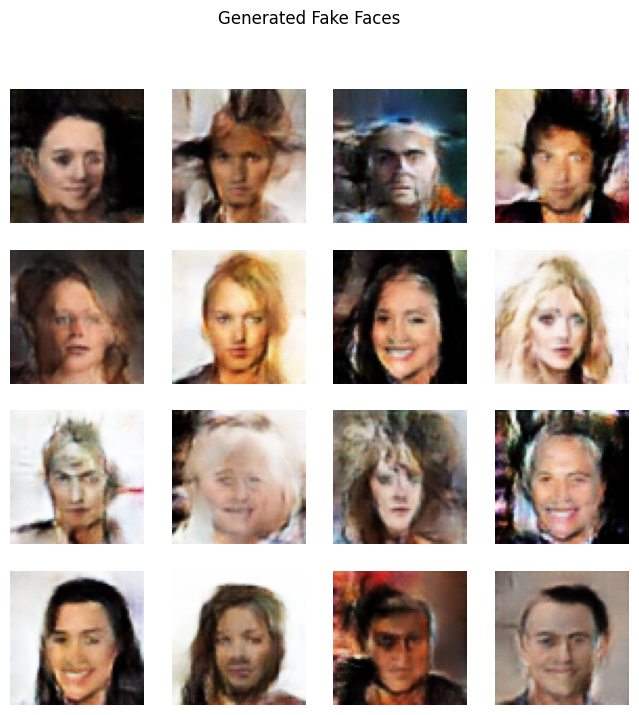

In [194]:
# Visualise Fake Faces
fig, axes = plt.subplots(4,4, figsize=(8,8))

for i, ax in enumerate(axes.flatten()):

    # Convert image format for plotting
    img = fake_images[i].permute(1,2,0)

    # Rescale from [-1,1] back to [0,1]
    img = (img + 1) / 2

    ax.imshow(img)
    ax.axis('off')

plt.suptitle("Generated Fake Faces")
plt.show()

In [144]:
# FFT DEEPFAKE DETECTION

In [195]:
# Prepare Real and Fake Images
# =========================
# GET REAL IMAGES
# =========================

real_images = []

# Take same number of real images as fake images
for i in range(len(fake_images)):

    # Get image from dataset
    img, _ = dataset[i]

    real_images.append(img)

# Stack images into tensor
real_images = torch.stack(real_images)

print("Real images shape:", real_images.shape)
print("Fake images shape:", fake_images.shape)

Real images shape: torch.Size([5000, 3, 64, 64])
Fake images shape: torch.Size([5000, 3, 64, 64])


In [196]:
# Convert Tensors to Numpy
# =========================
# CONVERT TO NUMPY
# =========================

# Convert tensors into numpy arrays

real_np = real_images.permute(0,2,3,1).numpy()

fake_np = fake_images.permute(0,2,3,1).numpy()

print(real_np.shape)
print(fake_np.shape)

(5000, 64, 64, 3)
(5000, 64, 64, 3)


In [197]:
# =========================
# FFT SPECTRUM FUNCTION > FFT allowed us to analyse hidden image frequency patterns, which helped reveal subtle artefacts commonly found in deepfake images
# =========================

import numpy as np

def to_log_spectrum(images):

    # Convert RGB images to grayscale
    gray = np.mean(images, axis=-1)

    # Apply Fast Fourier Transform
    fft = np.fft.fft2(gray)

    # Shift low frequencies to centre
    fft = np.fft.fftshift(fft)

    # Get magnitude spectrum
    magnitude = np.abs(fft)

    # Apply logarithm for visibility
    log_spectrum = np.log(magnitude + 1e-8)

    return log_spectrum

In [198]:
# Generate FFT Spectra
# =========================
# CREATE SPECTRA
# =========================

real_spec = to_log_spectrum(real_np)

fake_spec = to_log_spectrum(fake_np)

print("Real spectrum shape:", real_spec.shape)
print("Fake spectrum shape:", fake_spec.shape)

Real spectrum shape: (5000, 64, 64)
Fake spectrum shape: (5000, 64, 64)


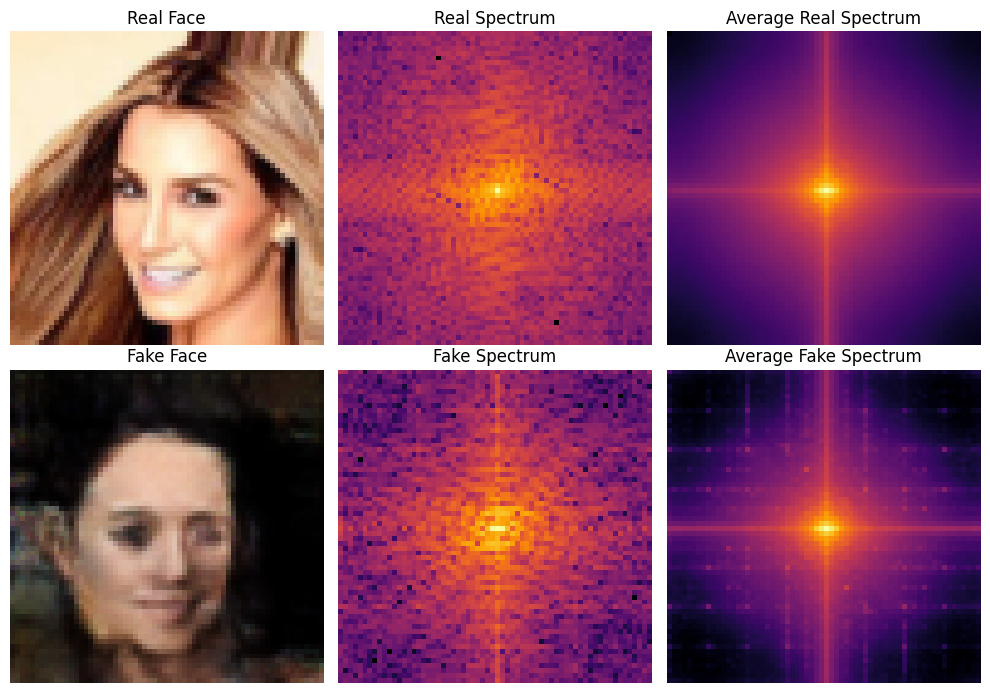

In [199]:
# =========================
# VISUALISE FFT SPECTRA
# =========================

fig, axes = plt.subplots(2,3, figsize=(10,7))

# REAL IMAGE
axes[0,0].imshow((real_np[0] + 1) / 2)
axes[0,0].set_title("Real Face")

# REAL SPECTRUM
axes[0,1].imshow(real_spec[0], cmap='inferno')
axes[0,1].set_title("Real Spectrum")

# AVERAGE REAL SPECTRUM
axes[0,2].imshow(np.mean(real_spec, axis=0), cmap='inferno')
axes[0,2].set_title("Average Real Spectrum")

# FAKE IMAGE
axes[1,0].imshow((fake_np[0] + 1) / 2)
axes[1,0].set_title("Fake Face")

# FAKE SPECTRUM
axes[1,1].imshow(fake_spec[0], cmap='inferno')
axes[1,1].set_title("Fake Spectrum")

# AVERAGE FAKE SPECTRUM
axes[1,2].imshow(np.mean(fake_spec, axis=0), cmap='inferno')
axes[1,2].set_title("Average Fake Spectrum")

# Remove axes
for ax in axes.flatten():
    ax.axis('off')

plt.tight_layout()
plt.show()

In [76]:
# TRAINING FFT DETECTOR

In [200]:
# =========================
# BUILD DATASET
# =========================

# Combine real + fake spectra
X = np.concatenate([real_spec, fake_spec], axis=0)

# Labels:
# 0 = real
# 1 = fake
y = np.concatenate([
    np.zeros(len(real_spec)),
    np.ones(len(fake_spec))
])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 64, 64)
y shape: (10000,)


In [201]:
# =========================
# FLATTEN SPECTRA
# =========================

X = X.reshape(X.shape[0], -1)

print("Flattened shape:", X.shape)

Flattened shape: (10000, 4096)


In [202]:
# =========================
# TRAIN TEST SPLIT
# =========================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.25,

    random_state=42,

    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 7500
Testing samples: 2500


In [203]:
# =========================
# LOGISTIC REGRESSION DETECTOR
# =========================

from sklearn.linear_model import LogisticRegression

# Create model
lr = LogisticRegression(max_iter=2000)

# Train model
lr.fit(X_train, y_train)

print("Training complete")

Training complete


In [204]:
# =========================
# EVALUATE DETECTOR
# =========================

from sklearn.metrics import (
    accuracy_score,
    classification_report
)

# Predictions
predictions = lr.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

# Full classification metrics
print(classification_report(
    y_test,
    predictions,
    target_names=["Real", "Fake"]
))

Accuracy: 0.9992
              precision    recall  f1-score   support

        Real       1.00      1.00      1.00      1250
        Fake       1.00      1.00      1.00      1250

    accuracy                           1.00      2500
   macro avg       1.00      1.00      1.00      2500
weighted avg       1.00      1.00      1.00      2500



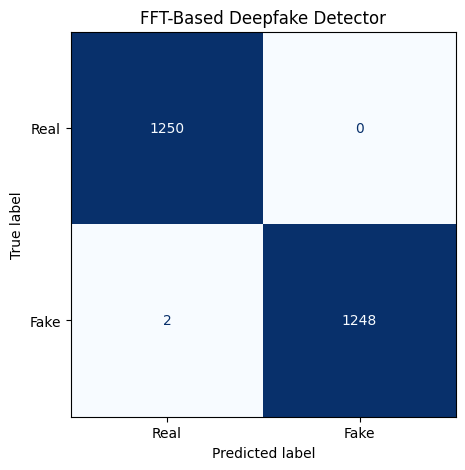

In [205]:
# =========================
# CONFUSION MATRIX
# =========================

from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(5,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    display_labels=["Real", "Fake"],
    cmap='Blues',
    colorbar=False,
    ax=ax
)

plt.title("FFT-Based Deepfake Detector")
plt.show()

In [207]:
from PIL import Image
import io

In [206]:
# =========================
# JPEG COMPRESSION FUNCTION
# =========================

def jpeg_compress(img_array, quality=50):

    # Convert image from [-1,1] to [0,255]
    img = ((img_array + 1) / 2 * 255).astype(np.uint8)

    # Convert to PIL image
    pil_img = Image.fromarray(img)

    # Save temporarily into memory buffer
    buffer = io.BytesIO()

    pil_img.save(buffer, format="JPEG", quality=quality)

    # Reload compressed image
    compressed = Image.open(buffer)

    # Convert back to numpy
    compressed = np.array(compressed).astype(np.float32)

    # Scale back to [-1,1]
    compressed = compressed / 255.0
    compressed = compressed * 2 - 1

    return compressed

In [208]:
# =========================
# APPLY JPEG COMPRESSION
# =========================

compressed_fake = []

for img in fake_np:

    compressed = jpeg_compress(img, quality=20)

    compressed_fake.append(compressed)

compressed_fake = np.array(compressed_fake)

print(compressed_fake.shape)

(5000, 64, 64, 3)


In [209]:
compressed_spec = to_log_spectrum(compressed_fake)

In [210]:
# Real test images
real_test = real_spec[:len(compressed_spec)]

# Combine
X_compressed = np.concatenate([
    real_test,
    compressed_spec
], axis=0)

# Labels
y_compressed = np.concatenate([
    np.zeros(len(real_test)),
    np.ones(len(compressed_spec))
])

# Flatten
X_compressed = X_compressed.reshape(
    X_compressed.shape[0],
    -1
)

In [211]:
compressed_predictions = lr.predict(X_compressed)

compressed_accuracy = accuracy_score(
    y_compressed,
    compressed_predictions
)

print("Compressed Accuracy:", compressed_accuracy)

print(classification_report(
    y_compressed,
    compressed_predictions,
    target_names=["Real", "Fake"]
))

Compressed Accuracy: 0.5757
              precision    recall  f1-score   support

        Real       0.54      1.00      0.70      5000
        Fake       1.00      0.15      0.26      5000

    accuracy                           0.58     10000
   macro avg       0.77      0.58      0.48     10000
weighted avg       0.77      0.58      0.48     10000



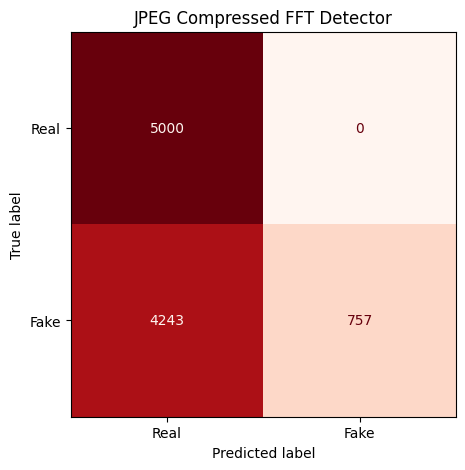

In [212]:
# =========================
# JPEG CONFUSION MATRIX
# =========================

fig, ax = plt.subplots(figsize=(5,5))

ConfusionMatrixDisplay.from_predictions(

    y_compressed,
    compressed_predictions,

    display_labels=["Real", "Fake"],

    cmap='Reds',

    colorbar=False,

    ax=ax
)

plt.title("JPEG Compressed FFT Detector")

plt.show()